In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/IPL.csv')
df.head(5)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [ ]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


In [ ]:
df.shape

(74, 20)

#**1. Which team won the most matches ?**

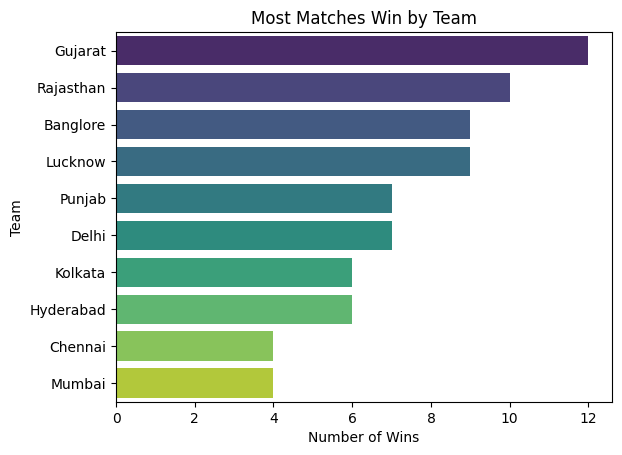

<Figure size 640x480 with 0 Axes>

In [ ]:
from ipywidgets.widgets.widget_int import Color
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index, x = match_wins.values, palette='viridis')
plt.title('Most Matches Win by Team')
plt.ylabel('Team')
plt.xlabel('Number of Wins')
plt.show()
plt.savefig('Most Matches Win by Team.png')

#**2. Toss Decision Trends**

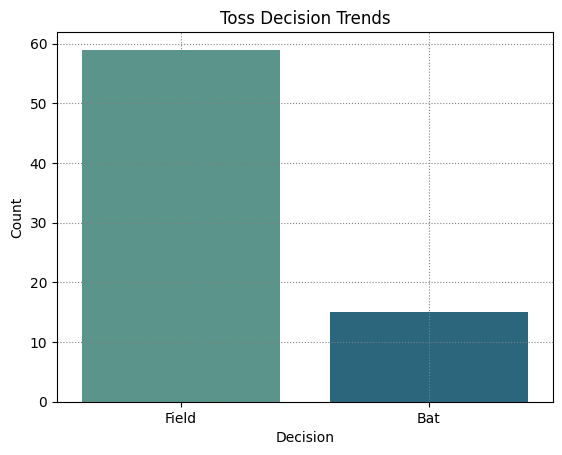

In [ ]:
sns.countplot(x = df['toss_decision'],palette='crest')
plt.title('Toss Decision Trends')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.grid(True, color='grey', linestyle='dotted')
plt.savefig('Toss Decision Trends.png')

#**3. Toss Winner VS Match Winner**

In [ ]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

#**4. How do teams wins ?(Runs vs Wickets)**

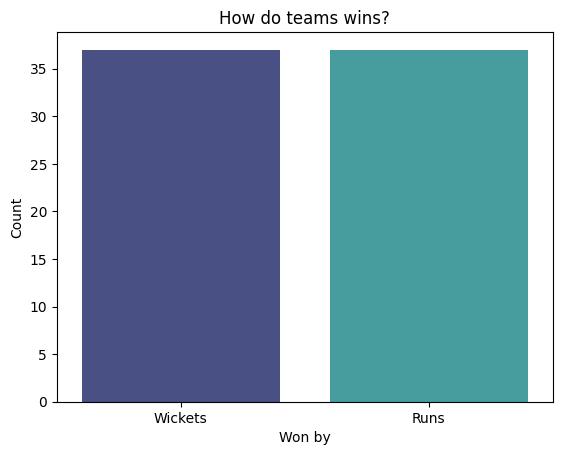

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.countplot(x = df['won_by'], palette='mako')
plt.title('How do teams wins?')
plt.xlabel('Won by')
plt.ylabel('Count')
plt.show()
plt.savefig('How do teams wins?.png')

#Key Player Performance

#**Most "Player of the Match" Awards**

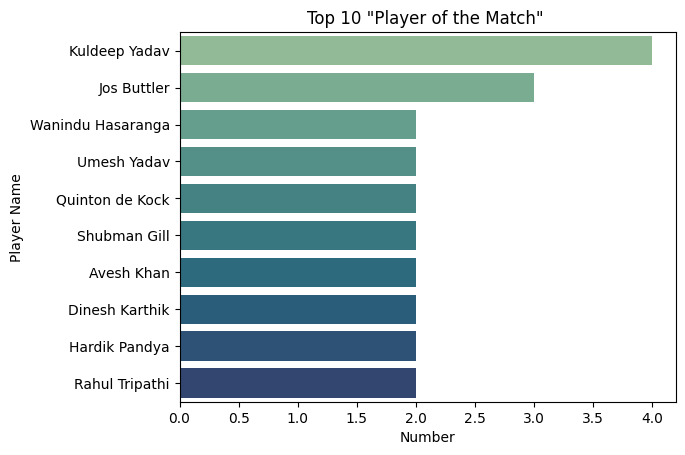

<Figure size 640x480 with 0 Axes>

In [ ]:
count = df['player_of_the_match'].value_counts().head(10)
sns.barplot(y = count.index, x = count.values, palette='crest')
plt.title('Top 10 "Player of the Match" ')
plt.xlabel('Number')
plt.ylabel('Player Name')
plt.show()
plt.savefig('Top 10 "Player of the Match" ')

#**Top 4 Scorers**

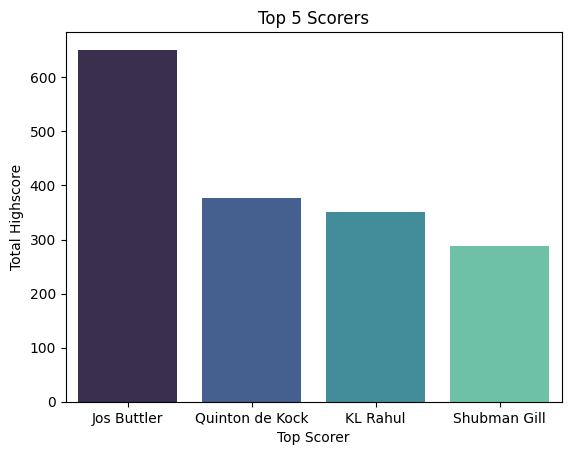

<Figure size 640x480 with 0 Axes>

In [ ]:
top_scorers = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(4)
sns.barplot(y=top_scorers.values, x=top_scorers.index, palette='mako')
plt.title('Top 5 Scorers')
plt.ylabel('Total Highscore')
plt.xlabel('Top Scorer')
plt.show()
plt.savefig('Top 5 Scorers.png')

#**Top 10 Bowling figure**

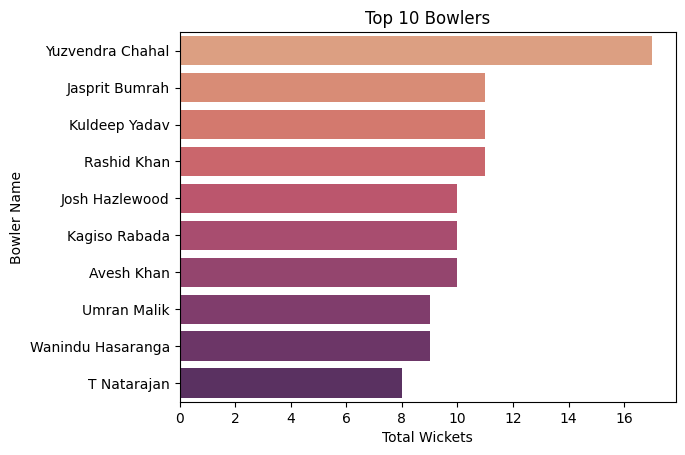

<Figure size 640x480 with 0 Axes>

In [ ]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_10_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=top_10_bowlers.index, x =top_10_bowlers.values, palette='flare')
plt.title('Top 10 Bowlers')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler Name')
plt.show()
plt.savefig('Top 10 Bowlers.png')

#Venue Analysis

In [ ]:
venue_count = df['venue'] .value_counts()
venue_count

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


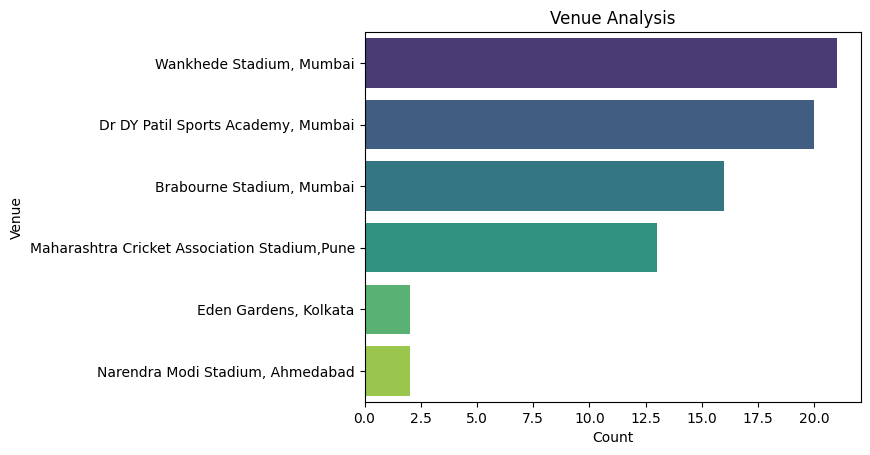

<Figure size 640x480 with 0 Axes>

In [ ]:
venue_count = df['venue'] .value_counts()
sns.barplot(y = venue_count.index, x = venue_count.values, palette='viridis')
plt.title('Venue Analysis')
plt.ylabel('Venue')
plt.xlabel('Count')
plt.show()
plt.savefig('Venue Analysis.png')

#**Who Won the highest margin  by runs ?**

In [ ]:
df[df['won_by'] == 'Runs'].sort_values(by= 'margin', ascending=False).head(1)[['match_winner', 'margin']]

,match_winner,margin
54,Chennai,91


#**Which Player had the highest individual score**

In [ ]:
df[df['highscore'] == df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


#**Which bowler had the best bowling figure**

In [ ]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
